## Importing btrack and loading example datasets

In [1]:
import btrack

from btrack import datasets

We can automatically download some example data to play with:

In [2]:
CONFIG_FILE = datasets.cell_config()
# SEGMENTATION_FILE = datasets.example_segmentation_file()
# OBJECTS_FILE = datasets.example_track_objects_file()

## Finding objects to track

### Use case 1 - Objects from segmentation

These could be objects found using algorithms such as a UNet, *CellPose* or *StarDist*. We can use `scikit-image` to load the segmentation data, which returns a numpy array of dimensions (T, Y, X).

In [3]:
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.util import montage

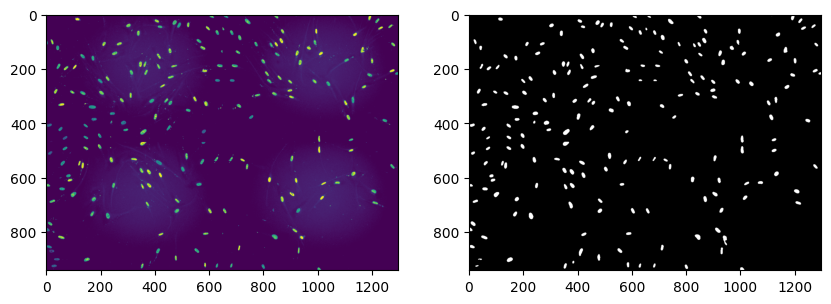

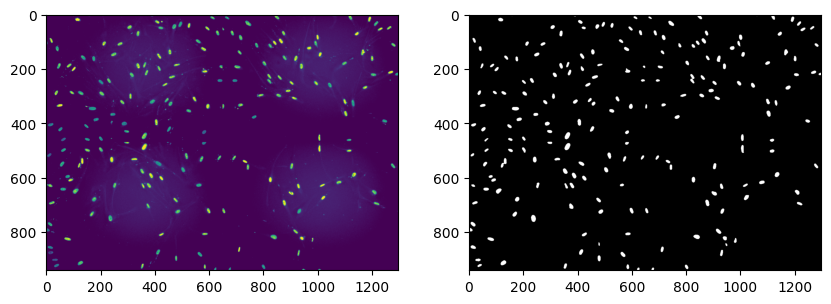

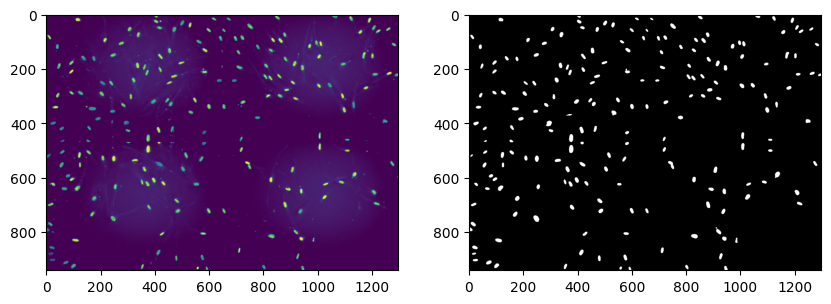

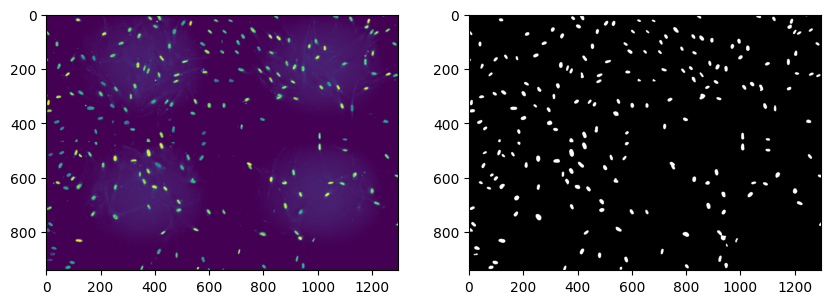

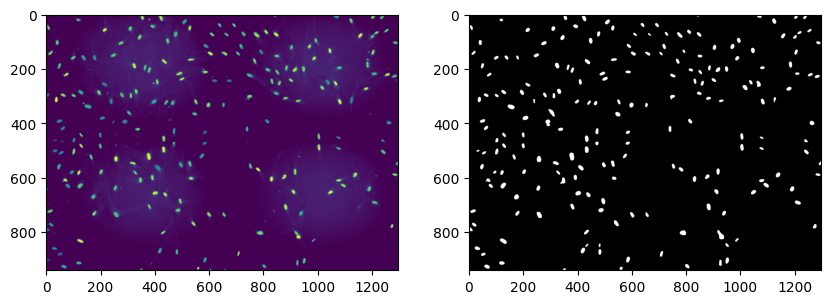

In [5]:
# Reload tifffiles back
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
from skimage import io

basepath = '/nfs/turbo/umms-indikar/Ram/development/projects/reprogramming/Hybrid-Reprogramming/data/imaging'
sample = 'Myod_PRRX1'
sample_id = 1
f_start = 1
f_end = 11
channel = 'cy5'
# num_frames = 30

cmap = ListedColormap(['black', 'white'])

original_imgs = [
    io.imread(f'{basepath}/original_images/{channel}/{sample}_{sample_id}_frame_{t:03d}.tif')
    for t in range(f_start, f_end)
]

segmentation_masks = [
    io.imread(f'{basepath}/segmentation_masks/{channel}/{sample}_{sample_id}_frame_{t:03d}.tif')
    for t in range(f_start, f_end)
]

# Convert to numpy arrays
originals = np.stack(original_imgs)
segmentations = np.stack(segmentation_masks)


for i in range(5):
    img = originals[i]
    mask = segmentations[i]
    full_mask = mask.copy()
    mask[mask > 1] = 1
    
    # print(mask)
    # print(mask.min(), mask.max())
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))
    ax1, ax2 = ax
    ax1.imshow(img)
    ax2.imshow(mask, cmap = cmap)

In [6]:
# # Reload tifffiles back
# import matplotlib.pyplot as plt
# import numpy as np
# from skimage import io


# # num_frames = 66
# num_frames = 60
# # num_frames = 30

# original_cy5_imgs = [
#     io.imread(f'mosaic_tiffs/original/{t}_cy5.tif')
#     for t in range(1, num_frames)
# ]

# original_mkate_imgs = [
#     io.imread(f'mosaic_tiffs/original/{t}_mkate.tif')
#     for t in range(1, num_frames)
# ]

# cy5_segmentation_masks = [
#     io.imread(f'mosaic_tiffs/segmentation/{t}_cy5.tif')
#     for t in range(1, num_frames)
# ]

# graphs = [
#     io.imread(f'mosaic_graphs/{t}.png')
#     for t in range(1, num_frames)
# ]

# imagexshape, imageyshape = original_cy5_imgs[0].shape

# graphr = [
#     io.imread(f'mosaic_graphs/{t}.png')[::, ::, :1].reshape(500, 1000)
#     for t in range(1, num_frames)
# ]
# graphg = [
#     io.imread(f'mosaic_graphs/{t}.png')[::, ::, 1:2].reshape(500, 1000)
#     for t in range(1, num_frames)
# ]
# graphb = [
#     io.imread(f'mosaic_graphs/{t}.png')[::, ::, 2:3].reshape(500, 1000)
#     for t in range(1, num_frames)
# ]

# graph_stack = np.zeros((num_frames, imagexshape+500, imageyshape+1000))  # 10 time points

# offset_x = imagexshape + 300
# offset_y = int(imageyshape//4.5)

# stack_with_image_r = np.zeros_like(graph_stack)
# stack_with_image_g = np.zeros_like(graph_stack)
# stack_with_image_b = np.zeros_like(graph_stack)

# for i in range(num_frames-1):
#     stack_with_image_r[i, offset_y:offset_y+500, offset_x:offset_x+1000] = image_to_add = graphr[i]
#     stack_with_image_g[i, offset_y:offset_y+500, offset_x:offset_x+1000] = image_to_add = graphg[i]
#     stack_with_image_b[i, offset_y:offset_y+500, offset_x:offset_x+1000] = image_to_add = graphb[i]


# # Convert to numpy arrays
# original_imgs = np.stack(original_cy5_imgs)
# # original_imgs = np.stack(original_mkate_imgs)
# segmentation_masks = np.stack(cy5_segmentation_masks)

# segmentation = segmentation_masks

# # for i in range(num_frames):
# #     img = original_cy5_imgs[i]
# #     mask = cy5_segmentation_masks[i]
# #     fig, ax = plt.subplots(figsize=(10, 10))
# #     ax.imshow(img)

In [7]:
# original_cy5_imgs[0].shape
# segmentation_masks.shape
# segmentation = segmentation_masks

In [8]:
segmentation_masks

[array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(942, 1298), dtype=uint16),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(942, 1298), dtype=uint16),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(942, 1298), dtype=uint16),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(942, 1298), dtype=uint16),
 array([[0, 0, 0

### show the segmentation as a montage

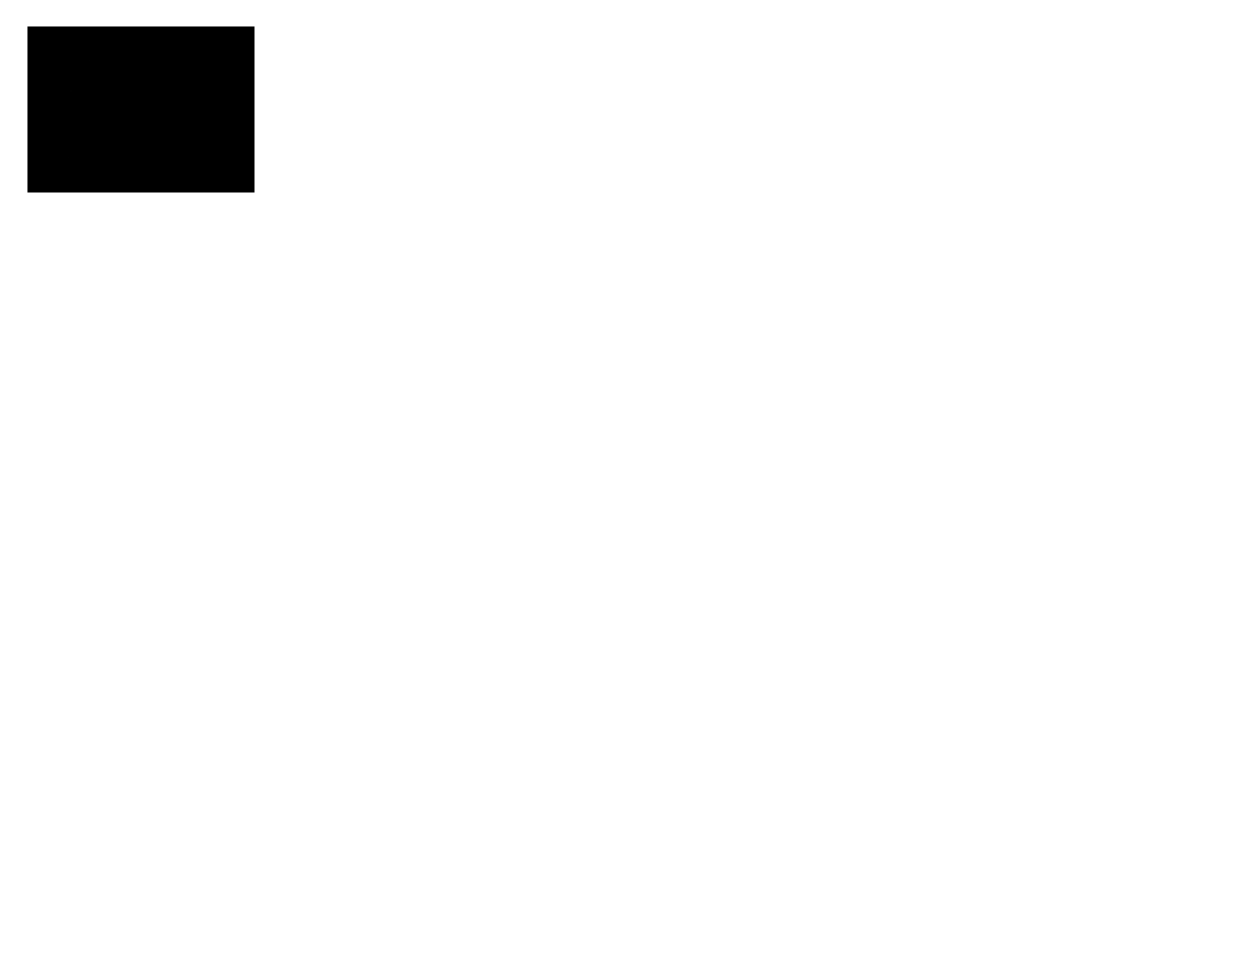

In [9]:
seq = montage(
    segmentations[::20, ::10, ::10], 
    grid_shape=(5, 5), 
    padding_width=10, 
    fill=255,
)

fig, ax = plt.subplots(1, figsize=(16, 16))
ax.imshow(seq, cmap=plt.cm.gray)
ax.axis(False)
plt.show()

### localize the objects

Now we use a utility function to localise the objects in the segmentation. Note that we can also use scikit-image `regionprops` to calculate properties for each object, using the `properties` keyword:

In [10]:
FEATURES = [
    "area", 
    "major_axis_length", 
    "minor_axis_length", 
    "orientation", 
    "solidity"
]

objects = btrack.utils.segmentation_to_objects(
    segmentations, 
    properties=tuple(FEATURES), 
    num_workers=16,  # parallelise this
)

[INFO][2025/07/29 05:31:58 PM] Localizing objects from segmentation...
[INFO][2025/07/29 05:31:58 PM] Processing using 16 workers.
100%|██████████| 10/10 [00:00<00:00, 29.36it/s]
[INFO][2025/07/29 05:31:58 PM] Objects are of type: <class 'dict'>
[INFO][2025/07/29 05:31:58 PM] ...Found 3395 objects in 10 frames.


We can also inspect each returned object to determine it's properties:

In [11]:
objects[0]
# len(objects)

,ID,x,y,z,t,dummy,states,label,area,major_axis_length,minor_axis_length,orientation,solidity
0,0,845.756906,7.906077,0.0,0,False,7,5,181.0,21.204374,10.917344,0.767725,0.957672


In [12]:
btrack.SystemInformation()

btrack_version: 0.6.5
system_platform: Linux-4.18.0-553.50.1.el8_10.x86_64-x86_64-with-glibc2.28
system_python: 3.12.9

## Run Tracking

In [13]:
# initialise a tracker session using a context manager
with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(CONFIG_FILE)
    tracker.max_search_radius = 50
    tracker.tracking_updates = ["MOTION", "VISUAL"]
    tracker.features = FEATURES

    # append the objects to be tracked
    tracker.append(objects)

    # set the tracking volume
    tracker.volume=((0, 1600), (0, 1200))

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks in a format for napari visualization
    data, properties, graph = tracker.to_napari()
    
    # store the tracks
    tracks = tracker.tracks
    
    # store the configuration
    cfg = tracker.configuration
    
    # export the track data 
    # tracker.export("tracks.h5", obj_type="obj_type_1")
    

[INFO][2025/07/29 05:32:00 PM] Loaded btrack: /home/nuvi/.local/lib/python3.12/site-packages/btrack/libs/libtracker.so
[INFO][2025/07/29 05:32:00 PM] Starting BayesianTracker session
[INFO][2025/07/29 05:32:00 PM] Loading configuration file: /home/nuvi/.cache/btrack-examples/examples/cell_config.json
[INFO][2025/07/29 05:32:00 PM] Objects are of type: <class 'list'>
[INFO][2025/07/29 05:32:00 PM] Starting tracking... 
[INFO][2025/07/29 05:32:00 PM] Update using: ['VISUAL', 'MOTION']
[INFO][2025/07/29 05:32:00 PM] Tracking objects in frames 0 to 10 (of 10)...
[INFO][2025/07/29 05:32:02 PM]  - Timing (Bayesian updates: 153.07ms, Linking: 3.92ms)
[INFO][2025/07/29 05:32:02 PM]  - Probabilities (Link: 0.99996, Lost: 0.99819)
[INFO][2025/07/29 05:32:02 PM] SUCCESS.
[INFO][2025/07/29 05:32:02 PM]  - Found 1162 tracks in 10 frames (in 0.0s)
[INFO][2025/07/29 05:32:02 PM]  - Inserted 256 dummy objects to fill tracking gaps
[INFO][2025/07/29 05:32:02 PM] Loading hypothesis model: cell_hypothesi

GLPK Integer Optimizer, v4.52
4648 rows, 5836 columns, 10568 non-zeros
5836 integer variables, all of which are binary
Preprocessing...
2324 rows, 5836 columns, 10568 non-zeros
5836 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 2324
Solving LP relaxation...
GLPK Simplex Optimizer, v4.52
2324 rows, 5836 columns, 10568 non-zeros
*     0: obj =   6.769186684e+03  infeas =  0.000e+00 (0)
*   500: obj =   4.147933788e+03  infeas =  0.000e+00 (0)
*  1000: obj =   2.898939167e+03  infeas =  0.000e+00 (0)
*  1500: obj =   2.547111557e+03  infeas =  0.000e+00 (0)
*  1506: obj =   2.547052860e+03  infeas =  0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
+  1506: mip =     not found yet >=              -inf        (1; 0)
+  2681: >>>>>   2.566453171e+03 >=   2.550912879e+03   0.6% (44; 0)
+  8117: >>>>>   

## Inspecting the output

We can also inspect each returned track to determine it's properties:

In [ ]:
tracks_bk = tracks

In [ ]:
cell = tracks[1]

In [ ]:
cell

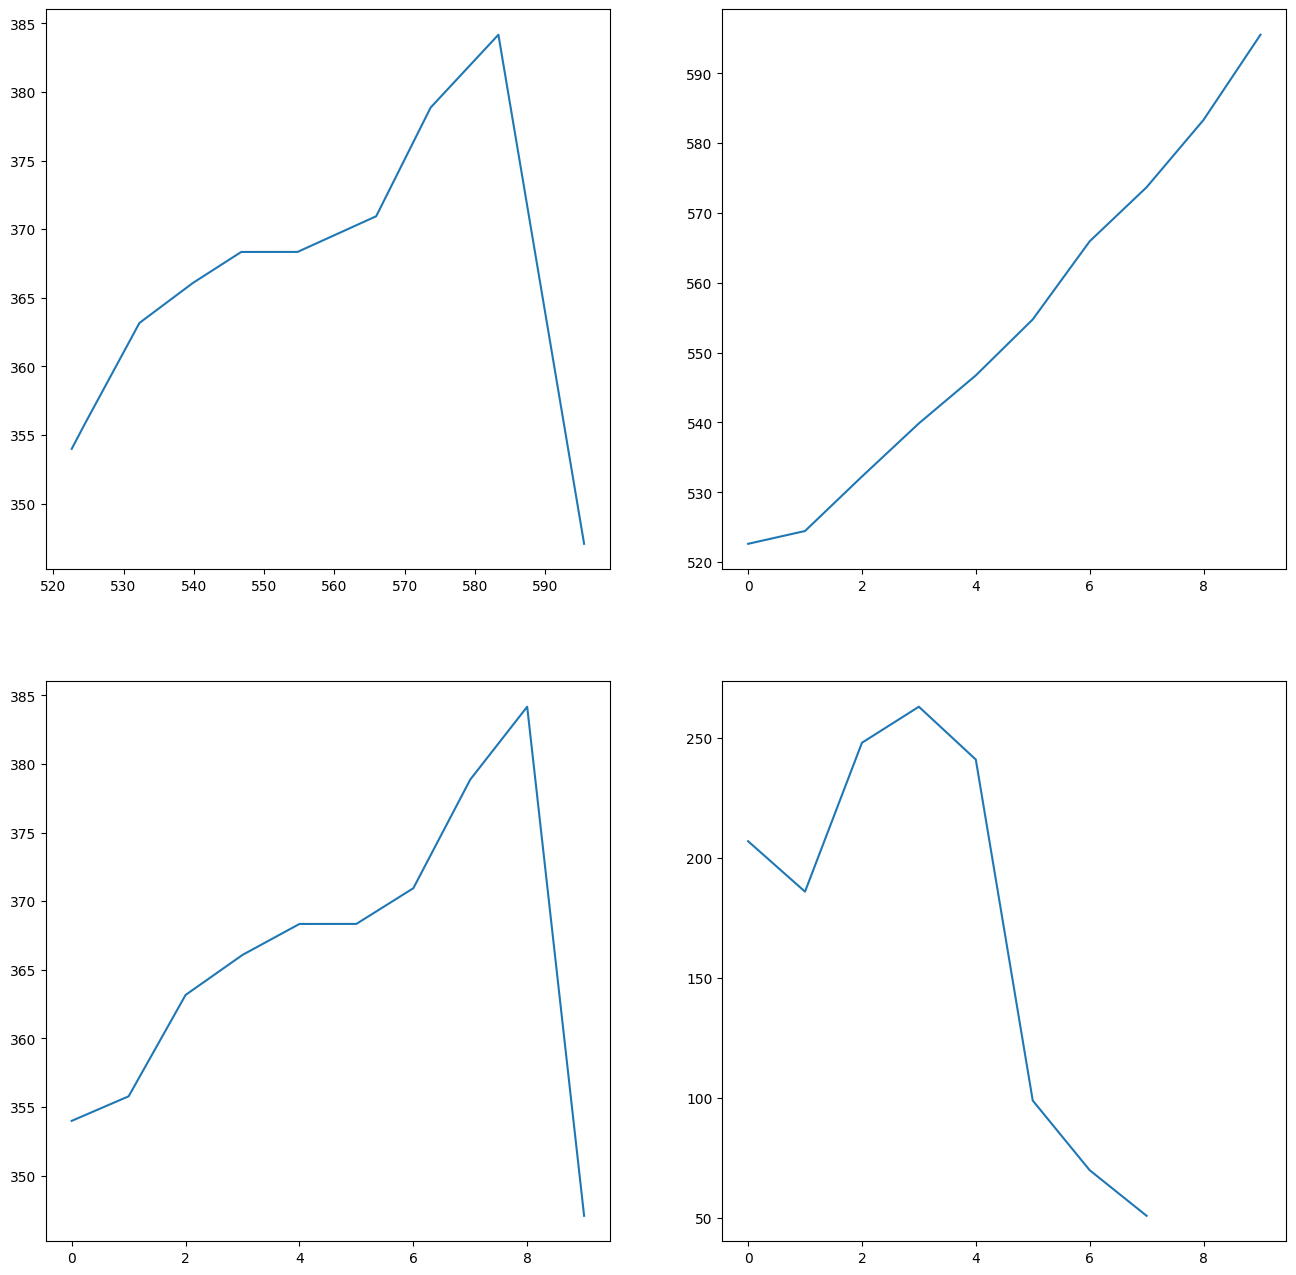

In [24]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 16))
ax1.plot(cell.x, cell.y)
ax2.plot(cell.t, cell.x)
ax3.plot(cell.t, cell.y)
ax4.plot(cell.t, cell["area"])
plt.show()

## Visualising the data with napari

Finally, we an inspect the entire tracking output using *napari*:

In [135]:
import napari


viewer = napari.Viewer()

viewer.add_image(
    segmentation, 
    name="Segmentation",
    opacity=0.3,
)

viewer.add_image(
    original_imgs, 
    name="Original Images",
    opacity=0.75,
)

# the track data from the tracker
viewer.add_tracks(
    data, 
    properties=properties, 
    graph=graph,
    name="Tracks", 
    blending="translucent",
    visible=True,
)

viewer.add_image(
    stack_with_image_r, 
    name="Graphr",
    colormap='red',
    opacity=0.7,
    blending='additive',
)
viewer.add_image(
    stack_with_image_g, 
    name="Graphg",
    colormap='green',
    opacity=0.7,
    blending='additive',
)
viewer.add_image(
    stack_with_image_b, 
    name="Graphb",
    colormap='blue',
    opacity=0.7,
    blending='additive',
)

napari.run()

Rendering frames...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:26<00:00,  2.25it/s]


In [ ]:
import napari


viewer = napari.Viewer()

viewer.add_image(
    segmentation, 
    name="Segmentation",
    opacity=0.5,
)

viewer.add_image(
    graphs, 
    name="PLOT",
    opacity=0.5,
)

# # the track data from the tracker
# viewer.add_tracks(
#     data, 
#     properties=properties, 
#     graph=graph,
#     name="Tracks", 
#     blending="translucent",
#     visible=True,
# )

napari.run()

In [33]:
# from napari.utils import nbscreenshot


# nbscreenshot(viewer)

In [54]:
import imageio

path_to_save_gif = 'gif.gif'

ims = [
    imageio.imread(f'mosaic_graphs/{t}.png')
    for t in range(num_frames)
]

imageio.mimwrite(path_to_save_gif, ims)

/var/folders/bw/k47pyks15hj5krd7g8r02s_c0000gn/T/ipykernel_90361/4144399679.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.imread(f'mosaic_graphs/{t}.png')


In [53]:
len(original_cy5_imgs)

59

In [34]:
# import sample data
from skimage.data import cells3d

import napari

# create a `Viewer` and `Image` layer here
viewer, image_layer = napari.imshow(cells3d())

# print shape of image data
print(image_layer.data.shape)

# start the event loop and show the viewer
napari.run()

(60, 2, 256, 256)


In [20]:
from skimage import data

import napari

viewer, image_layer = napari.imshow(data.astronaut(), rgb=True)

In [76]:
len(ims)

60

In [79]:
len(segmentation)

59